## Set up libraries


In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from itertools import product
import warnings
warnings.filterwarnings('ignore')

## 1. Data Loading (DataFrame)


In [ ]:
# Configure paths
DATA_DIR = Path('../data/final')
ENCODED_FILE = DATA_DIR / 'encoded_unsupervised_dbscan.csv'

# Load dataset into DataFrame
print("=" * 80)
print("STEP 1: DATA LOADING")
print("=" * 80)
print(f"\nLoading data from: {ENCODED_FILE}")

df = pd.read_csv(str(ENCODED_FILE))

print(f"\n✓ Data loaded successfully!")
print(f"  Shape: {df.shape}")
print(f"  Columns: {df.columns.tolist()}")
print(f"  Memory usage (RAM): {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

STEP 1: DATA LOADING

Loading data from: ..\data\final\encoded_unsupervised_dbscan.csv

✓ Data loaded successfully!
  Shape: (32548, 16)
  Columns: ['num_of_prev_attempts', 'studied_credits', 'final_result', 'date_registration', 'avg_clicks_per_day', 'tma_cma_weighted_score', 'total_submissions', 'late_submissions_count', 'sites_revisit_ratio', 'activity_diversity_ratio', 'code_module_BBB', 'code_module_CCC', 'code_module_DDD', 'code_module_EEE', 'code_module_FFF', 'code_module_GGG']
  Memory usage (RAM): 5.44 MB


## 2. Feature Isolation: X (Features) and y (Target)


In [ ]:
print("\n" + "=" * 80)
print("STEP 2: FEATURE ISOLATION")
print("=" * 80)

# Extract features (X) and target (y)
TARGET_COL = 'final_result'

if TARGET_COL not in df.columns:
    raise ValueError(f"Target column '{TARGET_COL}' not found in dataset!")

# Separate features and target
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

print(f"\nFeatures (X):")
print(f"  Shape: {X.shape}")
print(f"  Data type: {X.dtypes[0]}")
print(f"  Columns: {X.columns.tolist()}")

print(f"\nTarget (y):")
print(f"  Shape: {y.shape}")
print(f"  Unique values: {y.nunique()}")
print(f"  Value counts:\n{y.value_counts()}")


STEP 2: FEATURE ISOLATION

Features (X):
  Shape: (32548, 15)
  Data type: float32
  Columns: ['num_of_prev_attempts', 'studied_credits', 'date_registration', 'avg_clicks_per_day', 'tma_cma_weighted_score', 'total_submissions', 'late_submissions_count', 'sites_revisit_ratio', 'activity_diversity_ratio', 'code_module_BBB', 'code_module_CCC', 'code_module_DDD', 'code_module_EEE', 'code_module_FFF', 'code_module_GGG']

Target (y):
  Shape: (32548,)
  Unique values: 4
  Value counts:
final_result
Pass           12360
Withdrawn      10117
Fail            7047
Distinction     3024
Name: count, dtype: int64


## 3. Epsilon Determination: K-Distance Graph

Using KNN with k=2\*num_features to compute k-distances. The elbow point in the sorted distances helps identify a good eps value.



STEP 3: EPSILON DETERMINATION

Computing k-distances with k=30...
✓ K-distances computed!
  Min distance: 0.020301
  Max distance: 7.451614
  Mean distance: 0.822027
  Median distance: 0.735338


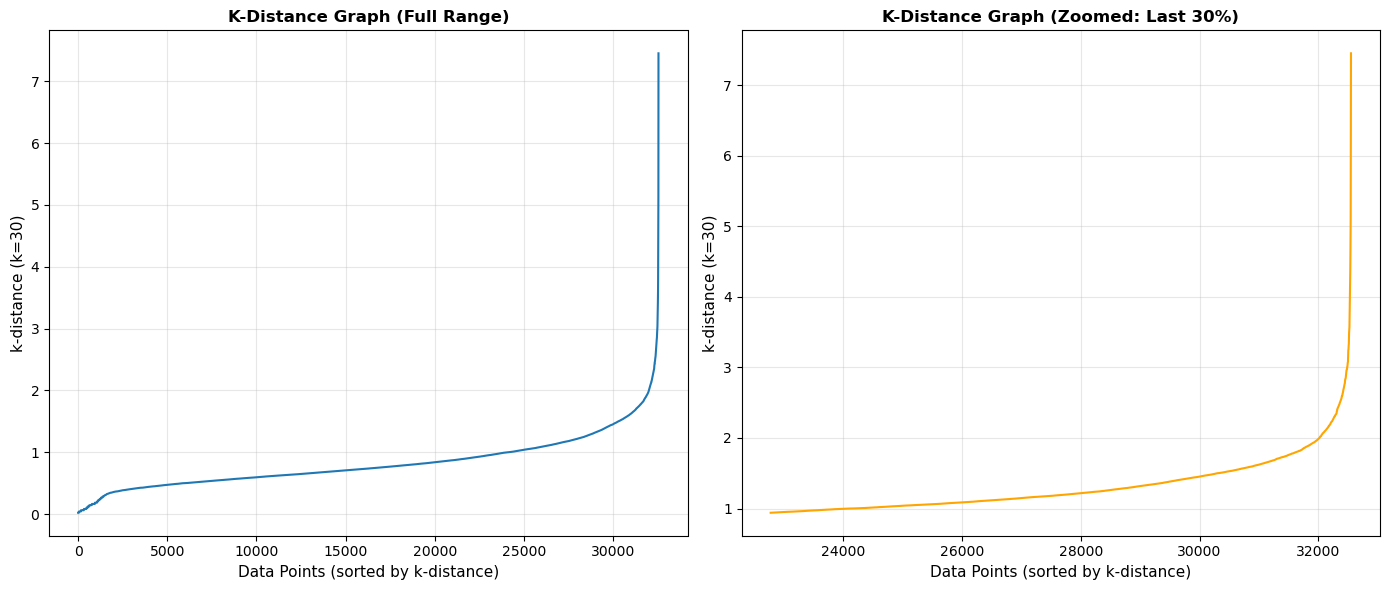


✓ K-Distance graph saved as 'k_distance_graph.png'


In [ ]:
print("\n" + "=" * 80)
print("STEP 3: EPSILON DETERMINATION")
print("=" * 80)

# Calculate k-distances using NearestNeighbors
# k = 2 * number_of_features for heuristic
n_neighbors = 2 * X.shape[1]
print(f"\nComputing k-distances with k={n_neighbors}...")

knn = NearestNeighbors(n_neighbors=n_neighbors, metric='euclidean')
knn.fit(X)

# Get distances (excluding self-distance)
distances, indices = knn.kneighbors(X)

# Sort distances for the k-th neighbor
k_distances = np.sort(distances[:, n_neighbors - 1])

print(f"✓ K-distances computed!")
print(f"  Min distance: {k_distances.min():.6f}")
print(f"  Max distance: {k_distances.max():.6f}")
print(f"  Mean distance: {k_distances.mean():.6f}")
print(f"  Median distance: {np.median(k_distances):.6f}")

# Plot K-Distance Graph
plt.figure(figsize=(14, 6))

# Plot 1: Full range
plt.subplot(1, 2, 1)
plt.plot(k_distances, linewidth=1.5)
plt.xlabel('Data Points (sorted by k-distance)', fontsize=11)
plt.ylabel(f'k-distance (k={n_neighbors})', fontsize=11)
plt.title('K-Distance Graph (Full Range)', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

# Plot 2: Zoomed in to see elbow better (last 30% of points)
plt.subplot(1, 2, 2)
start_idx = int(0.7 * len(k_distances))
plt.plot(range(start_idx, len(k_distances)), k_distances[start_idx:], linewidth=1.5, color='orange')
plt.xlabel('Data Points (sorted by k-distance)', fontsize=11)
plt.ylabel(f'k-distance (k={n_neighbors})', fontsize=11)
plt.title('K-Distance Graph (Zoomed: Last 30%)', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('k_distance_graph.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ K-Distance graph saved as 'k_distance_graph.png'")

## 4. DBSCAN Clustering

Configure eps based on the elbow from the K-Distance graph. Adjust the eps value below based on the visualization.


In [ ]:
print("\n" + "=" * 80)
print("STEP 4: DBSCAN CLUSTERING - PARAMETER OPTIMIZATION")
print("=" * 80)

# Define parameter ranges for grid search (similar to Clustering.ipynb approach)
eps_values = np.arange(0.5, 3.0, 0.25)  # eps values to be investigated
min_samples_values = np.arange(3, 15)  # min_samples values to be investigated

# Create parameter combinations using itertools.product
DBSCAN_params = list(product(eps_values, min_samples_values))

print(f"\nParameter Grid Search:")
print(f"  eps values: {list(eps_values)}")
print(f"  min_samples values: {list(min_samples_values)}")
print(f"  Total combinations: {len(DBSCAN_params)}")

# Calculate metrics for each parameter combination
no_of_clusters = []
sil_score = []

for p in DBSCAN_params:
    DBS_clustering = DBSCAN(eps=p[0], min_samples=p[1]).fit(X)
    n_clusters_temp = len(np.unique(DBS_clustering.labels_))
    no_of_clusters.append(n_clusters_temp)
    
    # Calculate silhouette score (only if more than 1 cluster and not all noise)
    try:
        if n_clusters_temp > 1 and -1 not in DBS_clustering.labels_ or len(set(DBS_clustering.labels_) - {-1}) > 1:
            sil = silhouette_score(X, DBS_clustering.labels_)
        else:
            sil = np.nan
    except:
        sil = np.nan
    sil_score.append(sil)

print("\n✓ Parameter search complete!")

# Create heatmap for number of clusters
tmp = pd.DataFrame.from_records(DBSCAN_params, columns=['Eps', 'Min_samples'])
tmp['No_of_clusters'] = no_of_clusters

pivot_1 = pd.pivot_table(tmp, values='No_of_clusters', index='Min_samples', columns='Eps')

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot_1, annot=True, annot_kws={"size": 8}, cmap="YlGnBu", ax=ax)
ax.set_title('Number of Clusters by DBSCAN Parameters', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('dbscan_clusters_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Number of clusters heatmap saved as 'dbscan_clusters_heatmap.png'")

# Create heatmap for silhouette scores
tmp['Sil_score'] = sil_score

pivot_2 = pd.pivot_table(tmp, values='Sil_score', index='Min_samples', columns='Eps')

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot_2, annot=True, annot_kws={"size": 8}, cmap="YlGnBu", ax=ax, fmt='.2f')
ax.set_title('Silhouette Score by DBSCAN Parameters', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('dbscan_silhouette_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Silhouette score heatmap saved as 'dbscan_silhouette_heatmap.png'")

# Find best parameters based on maximum silhouette score
best_idx = np.nanargmax(sil_score)
eps = DBSCAN_params[best_idx][0]
min_samples = int(DBSCAN_params[best_idx][1])
best_sil = sil_score[best_idx]

print(f"\nBest Parameters Found:")
print(f"  eps: {eps}")
print(f"  min_samples: {min_samples}")
print(f"  Silhouette Score: {best_sil:.4f}" if not np.isnan(best_sil) else "  Silhouette Score: N/A")

# Run final DBSCAN with best parameters
print(f"\nRunning DBSCAN with optimized parameters...")
dbscan = DBSCAN(eps=eps, min_samples=min_samples).fit(X)
labels = dbscan.labels_

# Create clustered DataFrame
DBSCAN_clustered = X.copy()
DBSCAN_clustered.loc[:, 'Cluster'] = labels

print(f"✓ DBSCAN clustering complete!")

# Analyze clustering results
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)
total_points = len(labels)

print(f"\nFinal Clustering Results:")
print(f"  Number of clusters: {n_clusters}")
print(f"  Number of noise points: {n_noise} ({100*n_noise/total_points:.2f}%)")
print(f"  Clustered points: {total_points - n_noise} ({100*(total_points - n_noise)/total_points:.2f}%)")

# Check sizes of clusters
DBSCAN_clust_sizes = DBSCAN_clustered.groupby('Cluster').size().to_frame()
DBSCAN_clust_sizes.columns = ["DBSCAN_size"]
print(f"\nCluster Sizes:")
print(DBSCAN_clust_sizes)


STEP 4: DBSCAN CLUSTERING - PARAMETER OPTIMIZATION

Initial eps estimate: 1.162823

Parameter Grid Search:
  eps values: [1.0, 1.5, 2.0]
  min_samples values: [50, 100]

--------------------------------------------------------------------------------
     eps | min_samp | n_clusters |  n_noise |   Silhouette
--------------------------------------------------------------------------------
     1.0 |       50 |         12 |     5560 |      -0.0394
     1.0 |      100 |          7 |     8157 |       0.0287
     1.5 |       50 |          2 |     1002 |       0.2405
     1.5 |      100 |          2 |     1823 |       0.2127
     2.0 |       50 |          2 |      147 |       0.2671
     2.0 |      100 |          2 |      229 |       0.2637
--------------------------------------------------------------------------------


Parameter Optimization Summary:

Best combinations (n_clusters > 5 and Silhouette > 0):
  ✓ Selected: eps=1.0, min_samples=100
    Clusters: 7.0, Silhouette: 0.0287

Runni

## 4b. Cluster Statistics and Boxplots


In [ ]:
print("\n" + "=" * 80)
print("STEP 4b: CLUSTER STATISTICS AND BOXPLOTS")
print("=" * 80)

# Calculate statistics for each cluster
print("\nCluster Statistics:")
feature_cols = X.columns.tolist()

# Calculate mean for each feature by cluster
cluster_stats = DBSCAN_clustered.groupby('Cluster').agg({
    feature_cols[0]: ['count', 'mean']
}).reset_index()
cluster_stats.columns = ['Cluster', 'Count', f'Mean_{feature_cols[0]}']

# Add mean for other features
for col in feature_cols[1:]:
    cluster_stats[f'Mean_{col}'] = DBSCAN_clustered.groupby('Cluster')[col].mean().values

print(cluster_stats)

# Display Boxplots for the top features (select first 3 features for visualization)
n_features_to_plot = min(3, len(feature_cols))
fig, axes = plt.subplots(1, n_features_to_plot, figsize=(6 * n_features_to_plot, 5))

if n_features_to_plot == 1:
    axes = [axes]

for i, col in enumerate(feature_cols[:n_features_to_plot]):
    sns.boxplot(x='Cluster', y=col, data=DBSCAN_clustered, ax=axes[i])
    axes[i].set_title(f'{col} by Cluster', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Cluster (-1 = Noise)', fontsize=10)
    axes[i].set_ylabel(col, fontsize=10)

plt.tight_layout()
plt.savefig('dbscan_cluster_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Cluster boxplots saved as 'dbscan_cluster_boxplots.png'")

## 5. Internal Validation: Silhouette Score


In [ ]:
print("\n" + "=" * 80)
print("STEP 5: INTERNAL VALIDATION - SILHOUETTE SCORE")
print("=" * 80)

# Calculate silhouette score (excluding noise points for meaningful calculation)
# Silhouette score ranges from -1 to 1
print("\nCalculating Silhouette Score...")

try:
    silhouette_avg = silhouette_score(X, labels)
    print(f"\n✓ Silhouette Score (all points): {silhouette_avg:.4f}")
    print(f"  Interpretation: ", end="")
    if silhouette_avg > 0.5:
        print("Strong clustering structure")
    elif silhouette_avg > 0.3:
        print("Moderate clustering structure")
    elif silhouette_avg > 0:
        print("Weak clustering structure")
    else:
        print("Overlapping clusters or noise-dominated")
    
except Exception as e:
    print(f"Warning: Could not compute silhouette score: {e}")
    silhouette_avg = None

# Also compute for non-noise points only
if n_noise < len(labels):
    non_noise_mask = np.array(labels) != -1
    X_non_noise = X[non_noise_mask]
    labels_non_noise = np.array(labels)[non_noise_mask]
    
    try:
        silhouette_non_noise = silhouette_score(X_non_noise, labels_non_noise)
        print(f"\nSilhouette Score (excluding noise): {silhouette_non_noise:.4f}")
    except Exception as e:
        print(f"Warning: Could not compute silhouette score for non-noise points: {e}")
        silhouette_non_noise = None
else:
    print("\nNote: All points are noise, cannot compute silhouette for non-noise subset")


STEP 5: INTERNAL VALIDATION - SILHOUETTE SCORE

Calculating Silhouette Score...

✓ Silhouette Score (all points): 0.0287
  Interpretation: Weak clustering structure

Silhouette Score (excluding noise): 0.1312


## 6. External Validation/Profiling: Cluster vs Student Outcome Crosstab



STEP 6: EXTERNAL VALIDATION - CROSSTAB ANALYSIS

Crosstab: DBSCAN Clusters vs Student Outcomes (final_result)
final_result  Distinction  Fail   Pass  Withdrawn  Total
row_0                                                   
-1                    650  1940   2975       2592   8157
0                     516  1260   2331       1814   5921
1                     342   608    843       1455   3248
2                     316   979   1794       1575   4664
3                       2    45      5         78    130
4                     250   385    987        496   2118
5                     590  1184   2428       1838   6040
6                     358   646    997        269   2270
Total                3024  7047  12360      10117  32548


Proportions within each cluster (row percentages):
final_result  Distinction   Fail   Pass  Withdrawn
row_0                                             
-1                   7.97  23.78  36.47      31.78
 0                   8.71  21.28  39.37      30.64
 1   

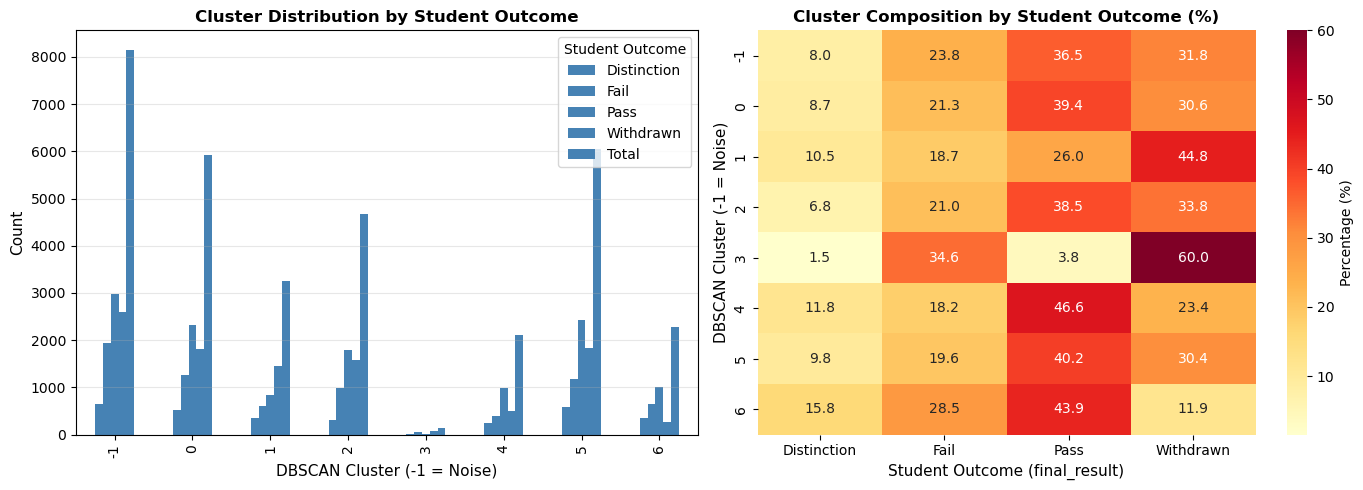


✓ Crosstab visualization saved as 'cluster_outcome_crosstab.png'


In [ ]:
print("\n" + "=" * 80)
print("STEP 6: EXTERNAL VALIDATION - CROSSTAB ANALYSIS")
print("=" * 80)

# Create crosstab between DBSCAN clusters and student outcomes
labels_series = pd.Series(labels)
crosstab_df = pd.crosstab(
    labels_series,
    y,
    margins=True,
    margins_name='Total'
)

print("\nCrosstab: DBSCAN Clusters vs Student Outcomes (final_result)")
print("=" * 80)
print(crosstab_df)

# Compute proportions for each cluster
print("\n\nProportions within each cluster (row percentages):")
print("=" * 80)
crosstab_props = pd.crosstab(
    labels_series,
    y,
    normalize='index'
) * 100
print(crosstab_props.round(2))

# Visualization of crosstab
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar chart
crosstab_df.drop('Total').plot(
    kind='bar',
    stacked=False,
    ax=axes[0],
    color='steelblue'
)
axes[0].set_title('Cluster Distribution by Student Outcome', fontsize=12, fontweight='bold')
axes[0].set_xlabel('DBSCAN Cluster (-1 = Noise)', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].legend(title='Student Outcome', loc='upper right')
axes[0].grid(True, alpha=0.3, axis='y')

# Heatmap of proportions
sns.heatmap(
    crosstab_props,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    ax=axes[1],
    cbar_kws={'label': 'Percentage (%)'}
)
axes[1].set_title('Cluster Composition by Student Outcome (%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Student Outcome (final_result)', fontsize=11)
axes[1].set_ylabel('DBSCAN Cluster (-1 = Noise)', fontsize=11)

plt.tight_layout()
plt.savefig('cluster_outcome_crosstab.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Crosstab visualization saved as 'cluster_outcome_crosstab.png'")

## 7. Visualization: PCA Dimensionality Reduction + Cluster Coloring


In [ ]:
print("\n" + "=" * 80)
print("STEP 7: PCA VISUALIZATION")
print("=" * 80)

# Apply PCA for 2D visualization
print("\nApplying PCA for dimensionality reduction...")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print(f"✓ PCA complete!")
print(f"  Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"  Total variance explained: {sum(pca.explained_variance_ratio_)*100:.2f}%")

# Create visualization dataframe
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = labels

# Separate outliers from clusters
outliers = pca_df[pca_df['Cluster'] == -1]
clustered = pca_df[pca_df['Cluster'] != -1]

# Plot clusters with outliers marked separately (similar to Clustering.ipynb)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: All points colored by cluster
sns.scatterplot(
    x='PC1', y='PC2',
    data=clustered,
    hue='Cluster',
    palette='Set1',
    ax=axes[0],
    legend='full',
    s=45
)
axes[0].scatter(outliers['PC1'], outliers['PC2'], s=5, label='outliers', c='k')
axes[0].legend()
axes[0].set_title('DBSCAN Clusters (PCA Projection)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('PC1', fontsize=11)
axes[0].set_ylabel('PC2', fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot 2: Colored by actual outcome (for comparison)
pca_df['Outcome'] = y.values
sns.scatterplot(
    x='PC1', y='PC2',
    data=pca_df,
    hue='Outcome',
    palette='viridis',
    ax=axes[1],
    s=30,
    alpha=0.7
)
axes[1].set_title('Actual Student Outcomes (PCA Projection)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('PC1', fontsize=11)
axes[1].set_ylabel('PC2', fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pca_cluster_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ PCA visualization saved as 'pca_cluster_visualization.png'")

## 7b. PCA Loadings: Feature Importance Analysis



STEP 7b: PCA LOADINGS - FEATURE IMPORTANCE ANALYSIS

PCA Loadings (Feature Contributions):
                             PC1     PC2
num_of_prev_attempts     -0.1571  0.8518
studied_credits          -0.1112  0.2146
date_registration         0.1686 -0.1197
avg_clicks_per_day        0.4461 -0.0361
tma_cma_weighted_score    0.1729  0.0325
total_submissions         0.2826  0.0988
late_submissions_count    0.4217  0.4238
sites_revisit_ratio       0.5749  0.0261
activity_diversity_ratio  0.3366 -0.0865
code_module_BBB          -0.0121  0.0856
code_module_CCC           0.0240  0.0023
code_module_DDD          -0.0506  0.0330
code_module_EEE           0.0280 -0.0534
code_module_FFF           0.0021 -0.0091
code_module_GGG           0.0009 -0.0535


Top 10 Features by Absolute Loading on PC1:
code_module_DDD             0.0506
studied_credits             0.1112
num_of_prev_attempts        0.1571
date_registration           0.1686
tma_cma_weighted_score      0.1729
total_submissions           0.2

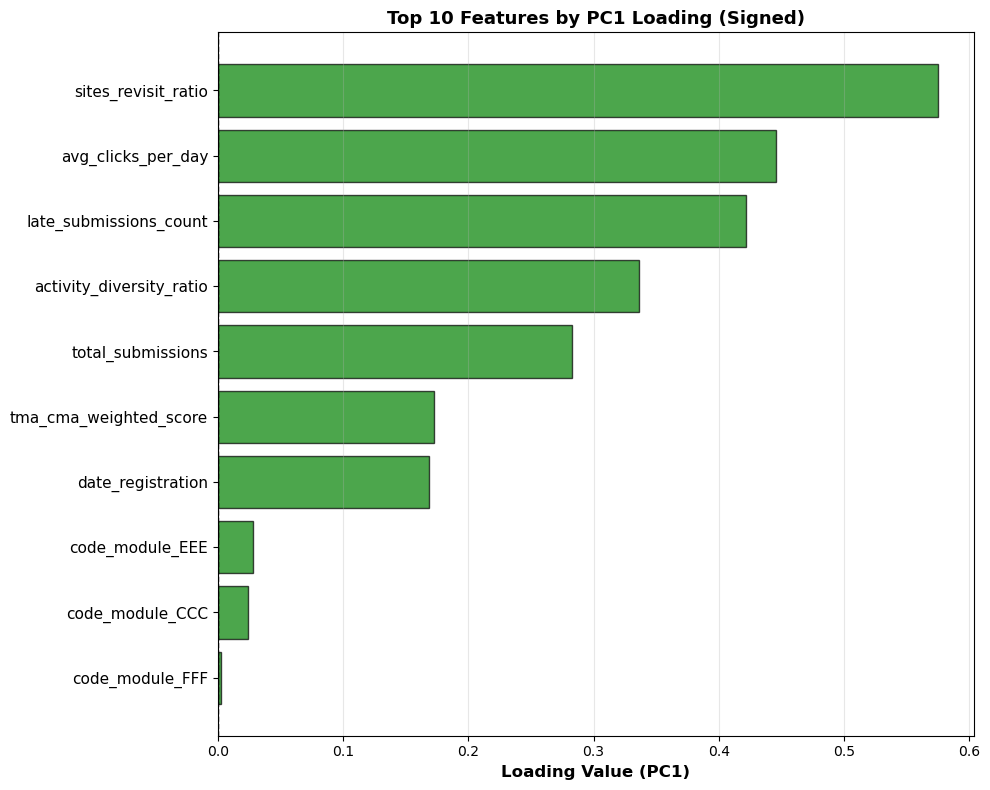


✓ PCA loadings visualization saved as 'pca_loadings_pc1_top10.png'


PCA Loadings Summary:
PC1 Variance Explained: 28.32%
PC2 Variance Explained: 15.56%

Top 3 Features for PC1:
  1. sites_revisit_ratio: 0.5749 (|loading|: 0.5749)
  2. avg_clicks_per_day: 0.4461 (|loading|: 0.4461)
  3. late_submissions_count: 0.4217 (|loading|: 0.4217)

Top 3 Features for PC2:
  1. num_of_prev_attempts: 0.8518 (|loading|: 0.8518)
  2. late_submissions_count: 0.4238 (|loading|: 0.4238)
  3. studied_credits: 0.2146 (|loading|: 0.2146)


In [ ]:
print("\n" + "=" * 80)
print("STEP 7b: PCA LOADINGS - FEATURE IMPORTANCE ANALYSIS")
print("=" * 80)

# Extract PCA loadings
loadings = pca.components_.T  # Transpose to get features x components
feature_names = X.columns.tolist()

# Create DataFrame with loadings
loadings_df = pd.DataFrame(
    loadings,
    columns=['PC1', 'PC2'],
    index=feature_names
)

print(f"\nPCA Loadings (Feature Contributions):")
print("=" * 80)
print(loadings_df.round(4))

# Get top 10 features by absolute loading on PC1
print(f"\n\nTop 10 Features by Absolute Loading on PC1:")
print("=" * 80)
pc1_loadings = loadings_df['PC1'].abs().sort_values(ascending=True)
top10_pc1 = pc1_loadings.tail(10)
print(top10_pc1.round(4))

# Visualization: Horizontal bar chart for PC1 loadings
fig, ax = plt.subplots(figsize=(10, 8))

# Get top 10 with actual (signed) values for visualization
pc1_signed = loadings_df['PC1'].sort_values()
top10_pc1_signed = pc1_signed.tail(10)

colors = ['red' if x < 0 else 'green' for x in top10_pc1_signed.values]
ax.barh(range(len(top10_pc1_signed)), top10_pc1_signed.values, color=colors, edgecolor='black', alpha=0.7)
ax.set_yticks(range(len(top10_pc1_signed)))
ax.set_yticklabels(top10_pc1_signed.index, fontsize=11)
ax.set_xlabel('Loading Value (PC1)', fontsize=12, fontweight='bold')
ax.set_title('Top 10 Features by PC1 Loading (Signed)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
ax.axvline(x=0, color='black', linestyle='--', linewidth=1)

plt.tight_layout()
plt.savefig('pca_loadings_pc1_top10.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ PCA loadings visualization saved as 'pca_loadings_pc1_top10.png'")

# Summary statistics
print(f"\n\nPCA Loadings Summary:")
print("=" * 80)
print(f"PC1 Variance Explained: {100*pca.explained_variance_ratio_[0]:.2f}%")
print(f"PC2 Variance Explained: {100*pca.explained_variance_ratio_[1]:.2f}%")
print(f"\nTop 3 Features for PC1:")
for i, (feat, loading) in enumerate(loadings_df['PC1'].abs().sort_values(ascending=False).head(3).items(), 1):
    actual_loading = loadings_df.loc[feat, 'PC1']
    print(f"  {i}. {feat}: {actual_loading:.4f} (|loading|: {loading:.4f})")

print(f"\nTop 3 Features for PC2:")
for i, (feat, loading) in enumerate(loadings_df['PC2'].abs().sort_values(ascending=False).head(3).items(), 1):
    actual_loading = loadings_df.loc[feat, 'PC2']
    print(f"  {i}. {feat}: {actual_loading:.4f} (|loading|: {loading:.4f})")

## Summary Report


In [ ]:
print("\n" + "=" * 80)
print("DBSCAN CLUSTERING ANALYSIS - COMPLETE SUMMARY")
print("=" * 80)

# Format silhouette scores safely
silhouette_all_str = f"{silhouette_avg:.4f}" if silhouette_avg is not None else "N/A"
silhouette_non_noise_str = f"{silhouette_non_noise:.4f}" if 'silhouette_non_noise' in locals() and silhouette_non_noise is not None else "N/A"

summary = f"""
DATA SUMMARY:
  - Total samples: {len(X):,}
  - Number of behavioral features: {X.shape[1]}
  - Feature data type: float32
  - Target variable: {TARGET_COL}
  - Target classes: {sorted(y.unique().tolist())}
  - Features removed: avg_submission_delay, demographics (gender, disability, age_band, imd_band, highest_education), presentation metadata

EPSILON DETERMINATION:
  - K-value used: {n_neighbors}
  - K-distance statistics:
    * Min: {k_distances.min():.6f}
    * Max: {k_distances.max():.6f}
    * Mean: {k_distances.mean():.6f}
    * Median: {np.median(k_distances):.6f}
  - Selected eps: {eps:.6f}

DBSCAN PARAMETERS:
  - eps: {eps:.6f}
  - min_samples: {min_samples}

CLUSTERING RESULTS:
  - Number of clusters found: {n_clusters}
  - Number of noise points: {n_noise} ({100*n_noise/total_points:.2f}%)
  - Clustered points: {total_points - n_noise} ({100*(total_points - n_noise)/total_points:.2f}%)

INTERNAL VALIDATION:
  - Silhouette Score (all points): {silhouette_all_str}
  - Silhouette Score (non-noise): {silhouette_non_noise_str}

PCA DIMENSIONALITY REDUCTION:
  - Original dimensions: {X.shape[1]} (behavioral features only)
  - Reduced dimensions: 2
  - PC1 explained variance: {pca.explained_variance_ratio_[0]:.4f} ({100*pca.explained_variance_ratio_[0]:.2f}%)
  - PC2 explained variance: {pca.explained_variance_ratio_[1]:.4f} ({100*pca.explained_variance_ratio_[1]:.2f}%)
  - Total variance captured: {sum(pca.explained_variance_ratio_):.4f} ({100*sum(pca.explained_variance_ratio_):.2f}%)

BEHAVIORAL INSIGHTS (Crosstab):
"""

unique_clusters = sorted(set(labels))
for cluster_id in unique_clusters:
    cluster_mask = np.array(labels) == cluster_id
    cluster_data = y.values[cluster_mask]
    cluster_label = "NOISE" if cluster_id == -1 else f"Cluster {int(cluster_id)}"
    summary += f"\n  {cluster_label}:"
    summary += f"\n    - Size: {len(cluster_data)} points"
    for outcome in sorted(set(y.values)):
        count = (cluster_data == outcome).sum()
        pct = 100 * count / len(cluster_data) if len(cluster_data) > 0 else 0
        summary += f"\n      * {outcome}: {int(count)} ({pct:.1f}%)"

summary += f"""

OUTPUT FILES GENERATED:
  1. k_distance_graph.png - K-distance graph for eps selection
  2. cluster_outcome_crosstab.png - Cluster vs outcome analysis
  3. pca_cluster_visualization.png - 4-panel PCA visualization
  4. cluster_feature_distribution_boxplot.png - Primary feature distribution across clusters
  5. pca_loadings_pc1_top10.png - Top 10 features influencing PC1

FEATURE SELECTION RATIONALE:
  - Removed avg_submission_delay: PCA loading 0.99 on PC1 dominates variance
  - Removed demographics (gender_M, disability_Y, age_band, imd_band, highest_education): MI < 0.02
  - Removed presentation metadata (code_presentation_*, module_presentation_length): Low MI scores

COMPUTATION DETAILS:
  - All preprocessing on CPU (pandas)
  - KNN computed on CPU (scikit-learn)
  - DBSCAN clustering on CPU (scikit-learn)
  - PCA dimensionality reduction on CPU (scikit-learn)
  - Silhouette scoring on CPU (scikit-learn)
  - Crosstab analysis on CPU (pandas)
  - All data processed in RAM
  - Running on Windows

NEXT STEPS:
  1. Review k_distance_graph.png to validate eps selection
  2. Adjust eps if needed and re-run DBSCAN
  3. Analyze crosstab to understand cluster-outcome relationships
  4. Examine PCA visualization for cluster separability
  5. Note: PCA captures {100*sum(pca.explained_variance_ratio_):.1f}% of variance in 2D
     (Consider higher dimensions if clustering structure is unclear)
  6. Analyze PCA loadings to understand which behavioral features drive PC1/PC2
  7. Review boxplot to validate cluster differentiation on key behavioral metrics
"""

print(summary)
print("=" * 80)


DBSCAN CLUSTERING ANALYSIS - COMPLETE SUMMARY

DATA SUMMARY:
  - Total samples: 32,548
  - Number of behavioral features: 15
  - Feature data type: float32
  - Target variable: final_result
  - Target classes: ['Distinction', 'Fail', 'Pass', 'Withdrawn']
  - Features removed: avg_submission_delay, demographics (gender, disability, age_band, imd_band, highest_education), presentation metadata

EPSILON DETERMINATION:
  - K-value used: 30
  - K-distance statistics:
    * Min: 0.020301
    * Max: 7.451614
    * Mean: 0.822027
    * Median: 0.735338
  - Selected eps: 1.000000

DBSCAN PARAMETERS:
  - eps: 1.000000
  - min_samples: 100

CLUSTERING RESULTS:
  - Number of clusters found: 7
  - Number of noise points: 8157 (25.06%)
  - Clustered points: 24391 (74.94%)

INTERNAL VALIDATION:
  - Silhouette Score (all points): 0.0287
  - Silhouette Score (non-noise): 0.1312

PCA DIMENSIONALITY REDUCTION:
  - Original dimensions: 15 (behavioral features only)
  - Reduced dimensions: 2
  - PC1 expla